# UNET SEGMENTATION

PyTorch Dataset for TIFF & Mask Pairs
This loader handles the conversion from raw temperature matrices (TIFF) to normalized $256 \times 256$ tensors, paired with your new PNG masks.

In [1]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


Initialization

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import tifffile as tiff
import cv2
import numpy as np
import os
import glob

class ThermalDataset(Dataset):
    def __init__(self, tiff_dir, mask_dir):
        # We find all masks first as they represent our ground truth batch
        self.mask_paths = glob.glob(os.path.join(mask_dir, "**", "*.png"), recursive=True)
        self.tiff_dir = tiff_dir
        self.mask_dir = mask_dir
        print(f"Dataset initialized with {len(self.mask_paths)} masks.")

    def __len__(self):
        return len(self.mask_paths)

    def __getitem__(self, idx):
        mask_path = self.mask_paths[idx]
        
        # 1. Get the patient folder and filename (e.g., Patient_106/benign/Right Lateral...)
        rel_path = os.path.relpath(mask_path, self.mask_dir)
        patient_subfolder = os.path.dirname(rel_path)
        mask_filename = os.path.basename(rel_path)
        
        # 2. Robust TIFF Search: Find the TIFF that matches the mask name
        # We search the folder directly to avoid encoding mismatches with the degree symbol
        tiff_search_folder = os.path.join(self.tiff_dir, patient_subfolder)
        base_name = os.path.splitext(mask_filename)[0]
        
        # We use a wildcard search to find the .tiff file matching the start of the mask name
        # This bypasses the specific encoding of the (90°) part
        search_pattern = os.path.join(tiff_search_folder, "*.tiff")
        potential_tiffs = glob.glob(search_pattern)
        
        tiff_path = None
        for p_tiff in potential_tiffs:
            if base_name[:10] in os.path.basename(p_tiff): # Match first 10 chars (e.g., 'Right Late')
                tiff_path = p_tiff
                break
        
        if tiff_path is None or not os.path.exists(tiff_path):
            raise FileNotFoundError(f"Could not find matching TIFF for {mask_path}")

        # 3. Load and Normalize TIFF (Paper Eq 1) [cite: 113]
        raw_data = tiff.imread(tiff_path)
        t_min, t_max = np.min(raw_data), np.max(raw_data)
        
        # Prevent division by zero
        if t_max == t_min:
            normalized = np.zeros_like(raw_data, dtype=np.float32)
        else:
            normalized = (raw_data - t_min) / (t_max - t_min)
            
        img_256 = cv2.resize(normalized.astype(np.float32), (256, 256), interpolation=cv2.INTER_AREA)

        # 4. Load Mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_256 = cv2.resize(mask, (256, 256)).astype(np.float32) / 255.0

        # Return as (C, H, W) tensors
        return torch.from_numpy(img_256).unsqueeze(0), torch.from_numpy(mask_256).unsqueeze(0)

# Paths
TIFF_BASE = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\organized_by_patient"
MASK_BASE = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\GroundTruth_Masks"

# Initialize
dataset = ThermalDataset(TIFF_BASE, MASK_BASE)
train_loader = DataLoader(dataset, batch_size=2, shuffle=True) # Batch size 2 as per paper

Dataset initialized with 50 masks.


U-Net Model based on paper

In [3]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True), # ReLU activator per paper [cite: 135]
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )
        
        self.enc1 = conv_block(1, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.bottleneck = conv_block(256, 512)
        
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)
        
        self.out = nn.Conv2d(64, 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(nn.MaxPool2d(2)(e1))
        e3 = self.enc3(nn.MaxPool2d(2)(e2))
        b = self.bottleneck(nn.MaxPool2d(2)(e3))
        
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.sigmoid(self.out(d1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)

Training with Adam Optimizer and BCE Loss

In [ ]:
pip install tqdm ipywidgets

In [6]:
from tqdm.notebook import tqdm # Progress bar for Jupyter/VS Code

# Define loss and optimizer per paper specifications
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) # Learning rate 1x10^-4 [cite: 136]

num_epochs = 100 # Total epochs defined in the methodology 

print(f"Starting Training on {device}...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    
    # Create a progress bar for the current epoch's batches
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    
    for imgs, masks in progress_bar:
        imgs, masks = imgs.to(device), masks.to(device)
        
        optimizer.zero_grad()
        output = model(imgs)
        loss = criterion(output, masks)
        
        loss.backward()
        optimizer.step()
        
        current_loss = loss.item()
        epoch_loss += current_loss
        
        # Update the progress bar with the current batch loss
        progress_bar.set_postfix(loss=f"{current_loss:.4f}")
    
    # Print the average loss for the epoch every 10 iterations
    avg_loss = epoch_loss / len(train_loader)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Summary -> Epoch [{epoch+1}/{num_epochs}] - Average Loss: {avg_loss:.4f}")

# Final save
torch.save(model.state_dict(), "breast_segmentation_unet.pth")
print("Training complete. Weights saved as 'breast_segmentation_unet.pth'.")

Starting Training on cpu...


Epoch 1/100:   0%|          | 0/25 [00:00<?, ?it/s]

Summary -> Epoch [1/100] - Average Loss: 0.6259


Epoch 2/100:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/25 [00:00<?, ?it/s]

...

Epoch 64/100:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 65/100:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 66/100:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 67/100:   0%|          | 0/25 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [7]:
torch.save(model.state_dict(), "breast_segmentation_unet_v1_60epochs.pth")
print("Weights saved successfully!")

Weights saved successfully!


In [10]:
pip install matplotlib pyplot

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pyplot (from versions: none)
ERROR: No matching distribution found for pyplot


In [31]:
import matplotlib.pyplot as plt
import random

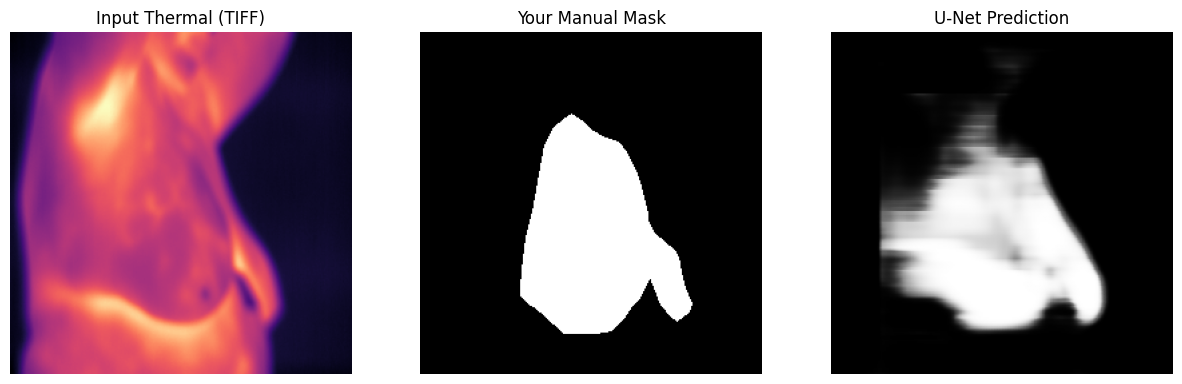

In [23]:
model.eval()
with torch.no_grad():
    # Grab a batch from the loader
    imgs, masks = next(iter(train_loader))
    imgs = imgs.to(device)
    
    # Predict
    preds = model(imgs)
    
    # Plot first item in batch
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(imgs[0,0].cpu(), cmap='magma')
    axs[0].set_title("Input Thermal (TIFF)")
    axs[1].imshow(masks[0,0].cpu(), cmap='gray')
    axs[1].set_title("Your Manual Mask")
    axs[2].imshow(preds[0,0].cpu(), cmap='gray')
    axs[2].set_title("U-Net Prediction")
    for ax in axs: ax.axis('off')
    plt.show()

Debug

Automated Inference and Otsu Filtering

In [28]:
output_edges = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges"

In [ ]:
def automated_segmentation(model_path, tiff_dir, output_dir):
    # Load the trained model
    model = UNet().to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # Find all original TIFFs
    all_tiffs = glob.glob(os.path.join(tiff_dir, "**", "*.tiff"), recursive=True)
    os.makedirs(output_dir, exist_ok=True)

    print(f"Running automated segmentation on {len(all_tiffs)} images...")

    for f_path in tqdm(all_tiffs):
        # 1. Load and Preprocess per paper Eq 1 [cite: 113, 115]
        raw = tiff.imread(f_path)
        t_min, t_max = np.min(raw), np.max(raw)
        norm = (raw - t_min) / (t_max - t_min + 1e-8)
        img_256 = cv2.resize(norm.astype(np.float32), (256, 256))
        
        # 2. U-Net Prediction [cite: 131]
        img_tensor = torch.from_numpy(img_256).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_tensor).squeeze().cpu().numpy()
        
        # 3. Suzuki/Binarization Filtering 
        binary = (pred > 0.5).astype(np.uint8) * 255
        
        # 4. Retain Largest Area 
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        clean_mask = np.zeros_like(binary)
        if contours:
            largest = max(contours, key=cv2.contourArea)
            cv2.drawContours(clean_mask, [largest], -1, 255, thickness=cv2.FILLED)
        
        # 5. Canny Edge Extraction 
        edges = cv2.Canny(clean_mask, 100, 200)

        # Save the finalized edge map
        rel_path = os.path.relpath(f_path, tiff_dir)
        out_name = os.path.splitext(rel_path)[0] + "_edge.png"
        save_path = os.path.join(output_dir, out_name)
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cv2.imwrite(save_path, edges)

# Run the automation
model_weights = "breast_segmentation_unet_v1_60epochs.pth"
automated_segmentation(model_weights, TIFF_BASE, output_edges)

Visualizing the Edges

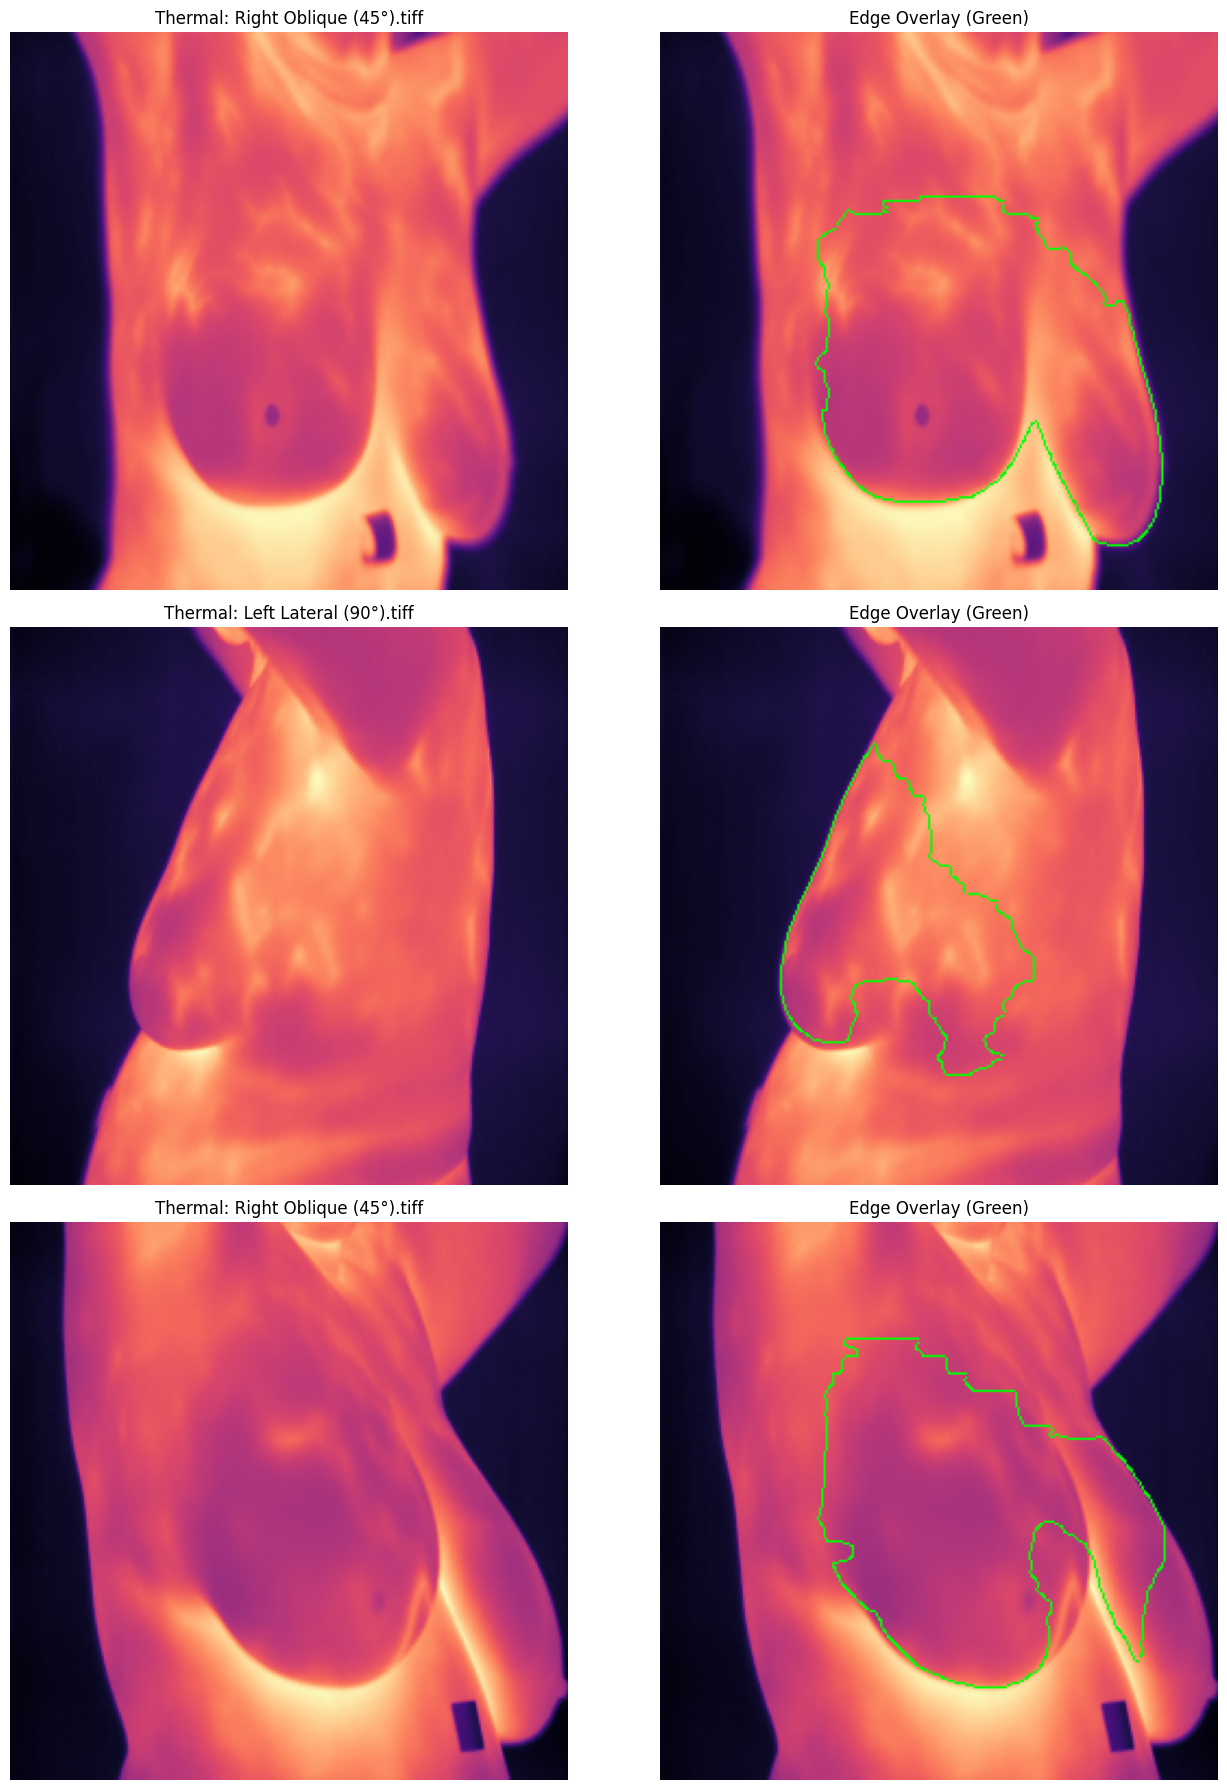

In [36]:
def robust_read_image(path, flags=cv2.IMREAD_GRAYSCALE):
    """Bypasses Windows path encoding issues and handles empty files."""
    try:
        if os.path.getsize(path) == 0: # Check if file was stopped mid-save
            return None
        # Read file as a numpy array buffer to bypass string encoding
        img_array = np.fromfile(path, dtype=np.uint8)
        img = cv2.imdecode(img_array, flags)
        return img
    except Exception:
        return None

def ultra_robust_light_test(tiff_dir, edge_dir, num_samples=3):
    # 1. Find all generated edge maps
    edge_files = glob.glob(os.path.join(edge_dir, "**", "*_edge.png"), recursive=True)
    
    if not edge_files:
        print("No edge files found! Check your Automated_Edges folder.")
        return

    # 2. Pick samples and setup plotting
    samples = random.sample(edge_files, min(num_samples, len(edge_files)))
    fig, axs = plt.subplots(len(samples), 2, figsize=(14, 6 * len(samples)))
    if len(samples) == 1: axs = np.expand_dims(axs, axis=0)

    for i, edge_path in enumerate(samples):
        # --- ROBUST READ ---
        edge_img = robust_read_image(edge_path)
        
        if edge_img is None:
            print(f"Skipping corrupted or unreadable edge map: {os.path.basename(edge_path)}")
            continue
        
        # 3. Find corresponding TIFF using Prefix Matching
        rel_path = os.path.relpath(edge_path, edge_dir)
        patient_subfolder = os.path.dirname(rel_path)
        edge_filename = os.path.basename(rel_path)
        search_folder = os.path.join(tiff_dir, patient_subfolder)
        search_prefix = edge_filename.split('(')[0].strip() 
        
        potential_tiffs = glob.glob(os.path.join(search_folder, "*.tiff"))
        tiff_path = next((p for p in potential_tiffs if search_prefix in os.path.basename(p)), None)
        
        if tiff_path is None:
            continue
            
        # 4. Load/Normalize TIFF and Resize to 256x256
        raw = tiff.imread(tiff_path)
        norm = 255 * (raw - np.min(raw)) / (np.max(raw) - np.min(raw) + 1e-8)
        norm_256 = cv2.resize(norm.astype(np.uint8), (256, 256), interpolation=cv2.INTER_AREA)
        base_display = cv2.applyColorMap(norm_256, cv2.COLORMAP_MAGMA)
        
        # 5. Overlay edges
        overlay = base_display.copy()
        # The 'if edge_img is not None' check prevents the TypeError
        overlay[edge_img > 0] = [0, 255, 0] 
        
        # Plotting
        axs[i, 0].imshow(cv2.cvtColor(base_display, cv2.COLOR_BGR2RGB))
        axs[i, 0].set_title(f"Thermal: {os.path.basename(tiff_path)}")
        axs[i, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axs[i, 1].set_title("Edge Overlay (Green)")
        for ax in axs[i]: ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Execute the test
ultra_robust_light_test(TIFF_BASE, output_edges, num_samples=3)

# Phase 3: Key Point Extraction ($P1, P2, P3$).


Step 3.1: Anchor Point Extraction Script

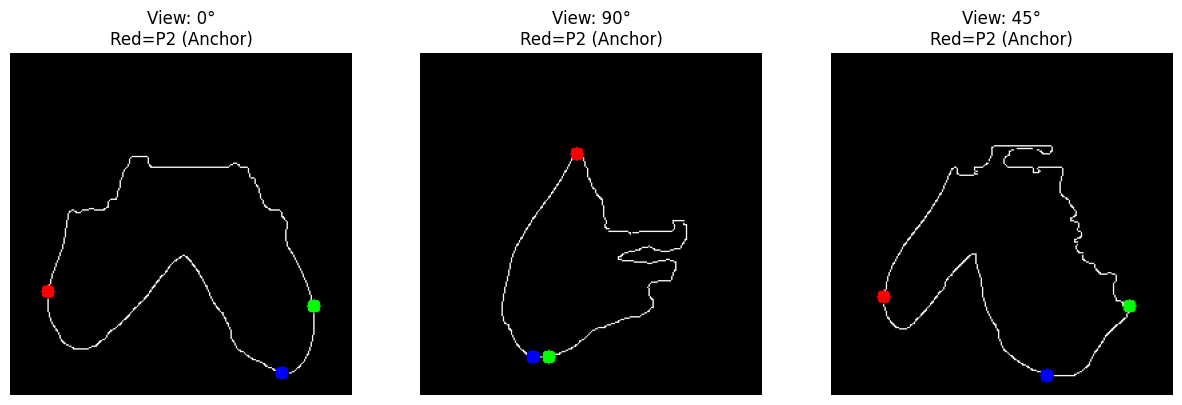

In [43]:
def extract_anchors_v2(edge_map, view_angle):
    # Ignore the top 30% of the image to remove neck/shoulder noise
    h, w = edge_map.shape
    edge_map[:int(h*0.7), :] = 0 
    
    coords = np.column_stack(np.where(edge_map > 0))
    if len(coords) < 10: return None
    
    # Focus P2 on the lowest 20% of the remaining ROI
    p2 = coords[np.argmax(coords[:, 0])] # Strictly the lowest pixel
    
    # For P1 and P3, find the widest points in the lower half
    lower_half = coords[coords[:, 0] > (h * 0.5)]
    p1 = lower_half[np.argmin(lower_half[:, 1])] # Far right
    p3 = lower_half[np.argmax(lower_half[:, 1])] # Far left
    
    return {"P1": p1, "P2": p2, "P3": p3}

def test_coordinate_extraction(edge_dir, patient_id="Patient_106"):
    # Find all edge maps for a specific patient
    patient_path = os.path.join(edge_dir, patient_id)
    edge_files = glob.glob(os.path.join(patient_path, "**", "*.png"), recursive=True)
    
    if not edge_files:
        print(f"No edges found for {patient_id}. Did you generate them?")
        return

    plt.figure(figsize=(15, 5))
    for i, f_path in enumerate(edge_files[:3]): # Test first 3 views
        # Determine angle from filename
        angle = 0
        if "90" in f_path: angle = 90
        elif "45" in f_path: angle = 45
        
        anchors = extract_anchors(f_path, angle)
        if not anchors: continue
        
        # Load for display
        img = cv2.imdecode(np.fromfile(f_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        
        # Draw the points: P1(Blue), P2(Red), P3(Green)
        cv2.circle(img, (anchors["P1"][1], anchors["P1"][0]), 5, (255, 0, 0), -1)
        cv2.circle(img, (anchors["P2"][1], anchors["P2"][0]), 5, (0, 0, 255), -1)
        cv2.circle(img, (anchors["P3"][1], anchors["P3"][0]), 5, (0, 255, 0), -1)
        
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(f"View: {angle}°\nRed=P2 (Anchor)")
        plt.axis('off')
    
    plt.show()

# Run the test on a patient you already generated
test_coordinate_extraction(output_edges, patient_id="Patient_106")